# Case study 1: Policy simulation with `its2s`

ITS counterfactual on simulated daily ED encounters (`case_study1_sim_data.ipynb`), using the **Prophet + XGBoost hybrid** (`prophet_xgb`).

- **Data:** `../data/sim_ed_encounters.csv` (2022–2026)
- **Intervention:** 2025-03-01
- **Known true effect:** +12% level shift → estimates should be close to +12%
- **Analysis:** `run_single_its` with package defaults (`its2s/params.yaml`)

In [1]:
from pathlib import Path
import logging
import warnings

import pandas as pd
from IPython.display import Image, display
from its2s import run_single_its

# Prophet/CmdStan log every bootstrap refit at INFO — keep notebook readable
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)
for _name in ("cmdstanpy", "prophet", "stan", "its2s", "xgboost", "matplotlib"):
    logging.getLogger(_name).setLevel(logging.WARNING)

DATA_PATH = Path("../data/sim_ed_encounters.csv")
OUT_DIR = Path("../outputs")
INTERVENTION = "2025-03-01"
TRUE_EFFECT_PCT = 12.0

df = pd.read_csv(DATA_PATH, parse_dates=["ds"]).sort_values("ds").reset_index(drop=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
result = run_single_its(
    df,
    intervention_date=INTERVENTION,
    output_dir=OUT_DIR,
)

print(result.summary())

Model: prophet_xgb
Bootstrap: 1000 simulations, 1000 successful

Train metrics:
  RMSE=22.0985  MAE=17.3232  MAPE=2.17%  R2=0.9096
Test metrics:
  RMSE=45.6061  MAE=32.8119  MAPE=3.86%  R2=0.6774

Total ATE: 67826.88 [58985.68, 74715.35]
Mean Daily ATE: 101.0833 [87.9071, 111.3493]
Holdout days: 671

Residual diagnostics:
  Mean=0.0113  Std=22.1105
  ACF(1)=-0.114  ACF(7)=-0.100  ACF(14)=-0.033
  Ljung-Box(10) p=0.0002
  Shapiro-Wilk p=0.0010


## Results: excess post-intervention

In [5]:
# results 

row = result.excess_table.period_excess.iloc[0]
est = row["excess_pct"]
# period CIs are on total excess (counts); convert to % for display
pct_lo = 100 * row["excess_ci_lo"] / row["total_expected"]
pct_hi = 100 * row["excess_ci_hi"] / row["total_expected"]

print(f"Simulated true effect          : +{TRUE_EFFECT_PCT:.1f}%")
print(f"Estimated attributable fraction: {est:+.2f}%  [95% CI: {pct_lo:+.2f}%, {pct_hi:+.2f}%]")
print(f"Difference (estimated − true)        : {est - TRUE_EFFECT_PCT:+.2f} pp")

Simulated true effect          : +12.0%
Estimated attributable fraction: +11.77%  [95% CI: +10.23%, +12.96%]
Difference (estimated − true)        : -0.23 pp


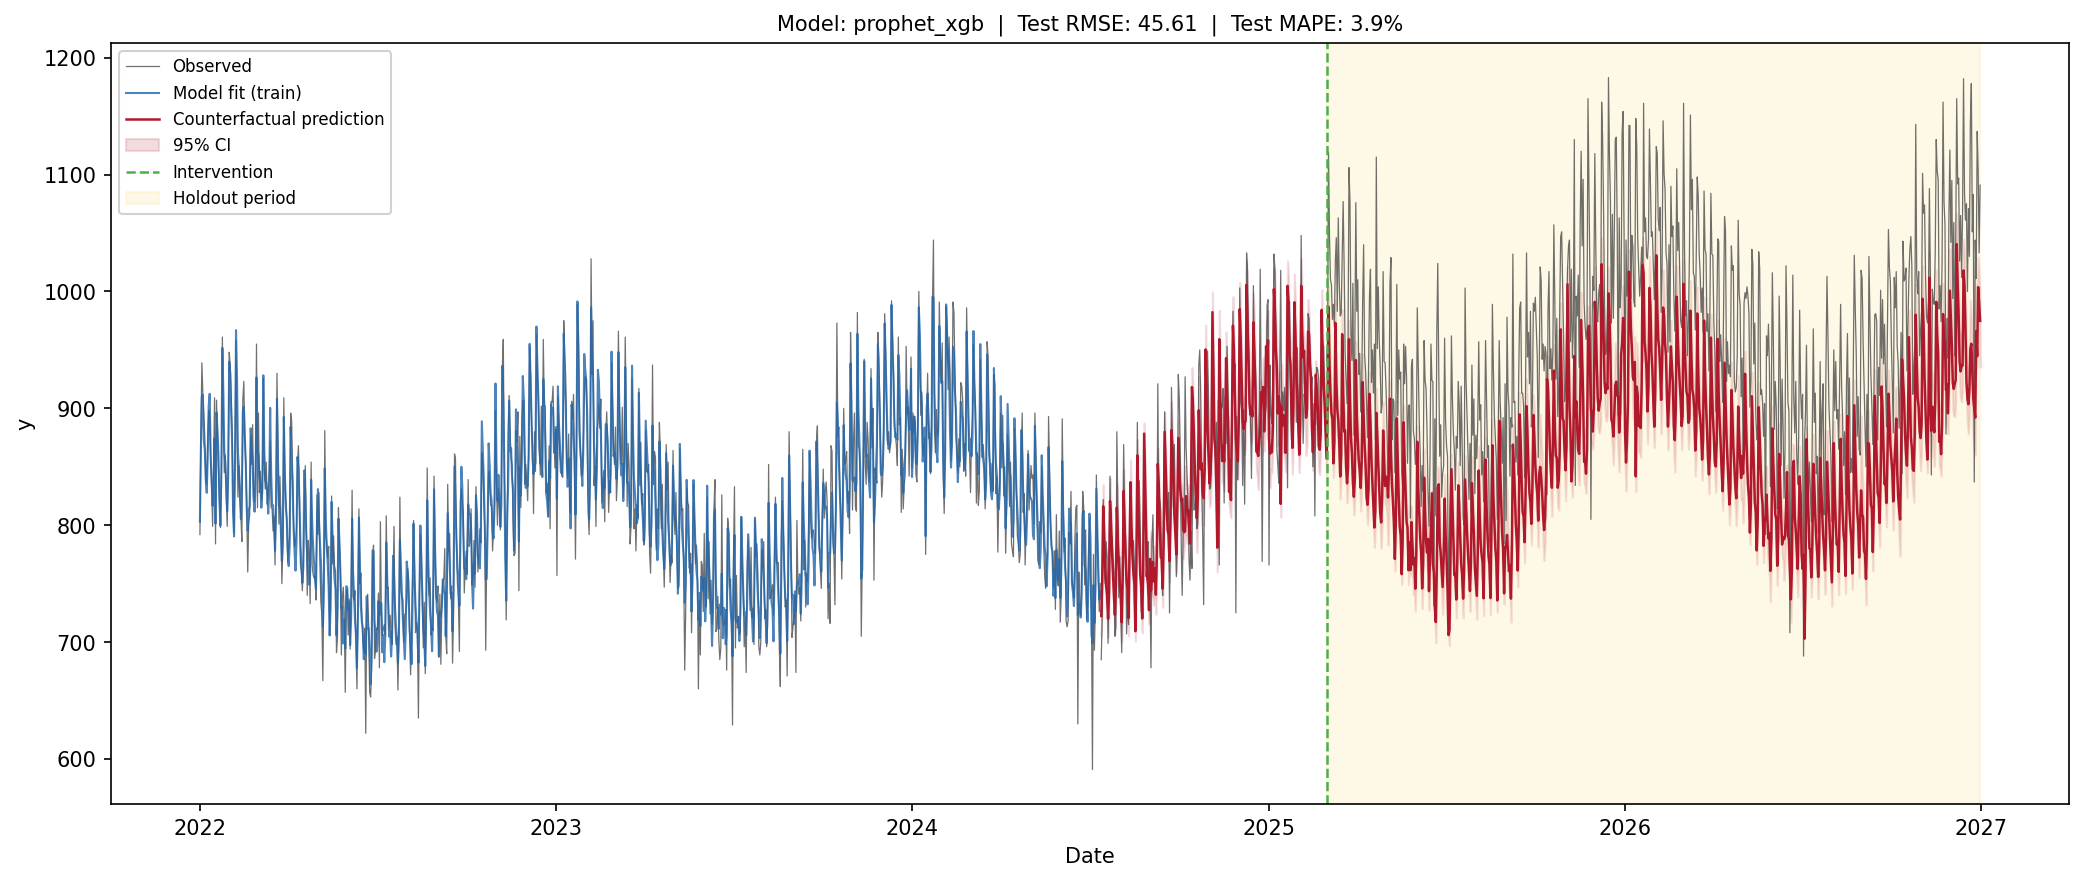

In [6]:
display(Image(filename=OUT_DIR / f"{result.model_name}_counterfactual.png"))